# Streaming density clustering — `DenStream` & `DbStream`

Two **online** density clusterers that live next to `Betula`. Both keep a small pool of *fading*
micro-clusters (recent data weighs more), so they track **evolving** streams and label sparse points
as noise (`-1`):

- **`DenStream`** (Cao et al., 2006) connects micro-clusters that are simply **close**.
- **`DbStream`** (Hahsler & Bolaños, 2016) connects them by **shared density** — the mass of points
  in their *overlap* — so it recovers arbitrary shapes **and** refuses to bridge two dense regions
  that merely sit close with an empty gap between them.

```bash
pip install betula-cluster matplotlib seaborn pandas networkx scikit-learn
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons

from betula_cluster import DbStream, DenStream

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (8, 5), "axes.titleweight": "bold"})
rng = np.random.default_rng(0)


def scatter(ax, X, labels, title):
    pal = {l: ("0.7" if l < 0 else sns.color_palette("tab10")[l % 10]) for l in set(labels)}
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette=pal, s=10, linewidth=0, legend=False, ax=ax)
    ax.set_title(title)
    ax.set(xlabel="", ylabel="")

## `DenStream` recovers non-convex shapes from a stream

We feed two interleaving moons in chunks (as if arriving over time), then label every point. `-1`
(grey) is noise that never joined a dense enough micro-cluster.

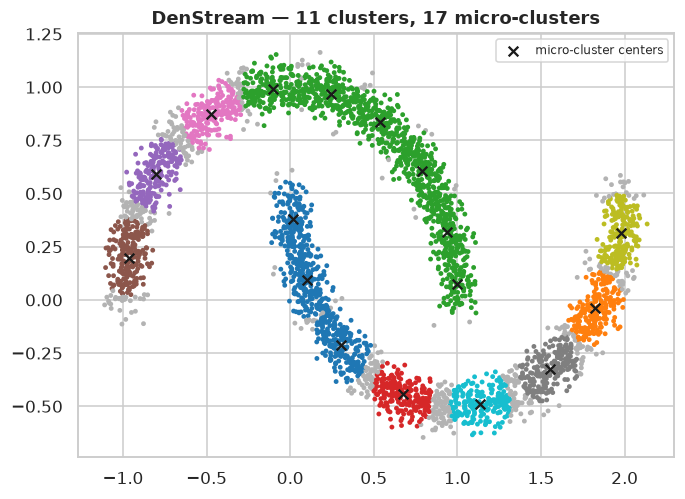

In [2]:
X, y = make_moons(n_samples=4000, noise=0.06, random_state=0)
X = X.astype(np.float64)

den = DenStream(eps=0.18, decay=0.001, beta=0.5, mu=6.0)
for chunk in np.array_split(rng.permutation(len(X)), 20):
    den.partial_fit(X[chunk])
labels = np.asarray(den.predict(X))

fig, ax = plt.subplots(figsize=(7, 5))
scatter(ax, X, labels, f"DenStream — {den.n_clusters_} clusters, {den.n_microclusters_} micro-clusters")
mc = den.microcluster_centers_
ax.scatter(mc[:, 0], mc[:, 1], c="k", marker="x", s=40, label="micro-cluster centers")
ax.legend(loc="upper right", fontsize=8)
plt.show()

## Fading: stale regions decay out

Stream an old blob, then a long run of points in a new, far-away region. With a non-trivial
`decay`, the old micro-clusters fade below the weight threshold and a query there returns noise.

In [3]:
old, _ = make_blobs(n_samples=200, centers=[[0, 0]], cluster_std=0.3, random_state=1)
new, _ = make_blobs(n_samples=4000, centers=[[12, 0]], cluster_std=0.3, random_state=2)
den2 = DenStream(eps=1.0, decay=0.05, beta=0.5, mu=6.0)
den2.partial_fit(old.astype(np.float64))
for chunk in np.array_split(new.astype(np.float64), 20):
    den2.partial_fit(chunk)

pts = np.array([[0.0, 0.0], [12.0, 0.0]])
probe = pd.DataFrame(
    {
        "region": ["old (0,0)", "new (12,0)"],
        "predicted label": np.asarray(den2.predict(pts)).tolist(),
    }
)
probe["verdict"] = np.where(probe["predicted label"] < 0, "faded → noise", "live cluster")
probe

,region,predicted label,verdict
0,"old (0,0)",-1,faded → noise
1,"new (12,0)",0,live cluster


## `DbStream` — shared density refuses false bridges

Two tight blobs whose centres are **within `2·r`** of each other (a distance-only rule would merge
them) but with an **empty gap** between. There is zero shared density across the gap, so `DbStream`
keeps them as two clusters.

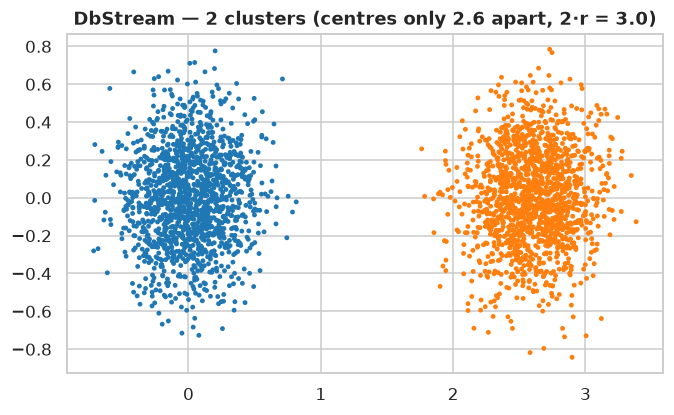

In [4]:
a = rng.normal([0.0, 0.0], 0.25, (1500, 2))
b = rng.normal([2.6, 0.0], 0.25, (1500, 2))
Xg = np.vstack([a, b])
db = DbStream(r=1.5, decay=0.0005, alpha=0.1, min_weight=3.0)
db.partial_fit(Xg)
gl = np.asarray(db.predict(Xg))

fig, ax = plt.subplots(figsize=(7, 4))
scatter(ax, Xg, gl, f"DbStream — {db.n_clusters_} clusters (centres only 2.6 apart, 2·r = 3.0)")
plt.show()

### The micro-cluster graph

Each node is a `DbStream` micro-cluster, placed at its centre and coloured by the cluster it landed
in; edges link micro-clusters whose centres are within `2·r`. The two colours are two connected
components — the empty gap leaves no edge across it.

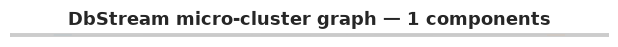

In [5]:
import networkx as nx

centers = db.microcluster_centers_
mlabels = np.asarray(db.predict(centers))
g = nx.Graph()
for i, c in enumerate(centers):
    g.add_node(i, pos=(float(c[0]), float(c[1])), label=int(mlabels[i]))
two_r = 3.0
for i in range(len(centers)):
    for j in range(i + 1, len(centers)):
        if np.linalg.norm(centers[i] - centers[j]) <= two_r:
            g.add_edge(i, j)

pos = nx.get_node_attributes(g, "pos")
node_col = [sns.color_palette("tab10")[g.nodes[i]["label"] % 10] for i in g.nodes]
fig, ax = plt.subplots(figsize=(7, 4))
nx.draw_networkx_edges(g, pos, alpha=0.3, ax=ax)
nx.draw_networkx_nodes(g, pos, node_color=node_col, node_size=120, ax=ax)
ax.set_title(f"DbStream micro-cluster graph — {nx.number_connected_components(g)} components")
ax.set_aspect("equal")
plt.show()

## When to reach for which

In [6]:
pd.DataFrame(
    {
        "head": ["DenStream", "DbStream"],
        "connects micro-clusters by": ["proximity (within 2·ε)", "shared density (overlap mass)"],
        "good for": ["evolving streams, noise", "arbitrary shapes, no false bridges"],
        "key params": ["eps, decay, beta, mu", "r, decay, alpha, min_weight"],
    }
)

,head,connects micro-clusters by,good for,key params
0,DenStream,proximity (within 2·ε),"evolving streams, noise","eps, decay, beta, mu"
1,DbStream,shared density (overlap mass),"arbitrary shapes, no false bridges","r, decay, alpha, min_weight"
